ACROSS-PARTICIPANT RSA

ISPC: correlates each participant's voxel pattern for each event with the group mean pattern for that event (excluding themselves)
separately for vice, virtue and non-moral sentences
average across left and right hemisphere
paired t test


In [1]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, zscore, ttest_rel, pearsonr, ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import seaborn as sns
from scipy.stats import sem
from scipy.signal import detrend


In [2]:
foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"

In [3]:
whichVersion = 'persentence' #persentence, 3sec, 6sec

In [4]:
# ------------------------
# Load 
# ------------------------

whichROI = "TPJ_refined_mask" # hippocampus

whichStory = "shapessocial"  # shapessocial, shapesphysical

base_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)

# make sure foundation scores for pretty mouth are found
if whichStory == 'prettymouthaffair':
    storyFile = 'prettymouth'
    foundationScores_file = f"{foundationScores_dir}{storyFile}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichStory == 'prettymouthparanoia':
    storyFile = 'prettymouth'
    foundationScores_file = f"{foundationScores_dir}{storyFile}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
else:
    print('use foundation scores of WhichStory')
    if whichVersion =='persentence':
        foundationScores_file = f"{foundationScores_dir}{whichStory}_MFT_MAC.xlsx"
        foundationScores = pd.read_excel(foundationScores_file)
    elif whichVersion =='3sec':
        foundationScores_file = f"{foundationScores_dir}{whichStory}_3_seconds_MFT_MAC.xlsx"
        foundationScores = pd.read_excel(foundationScores_file)
    elif whichVersion =='6sec':
        foundationScores_file = f"{foundationScores_dir}{whichStory}_6_seconds_MFT_MAC.xlsx"
        foundationScores = pd.read_excel(foundationScores_file)

print(whichStory)
print(whichROI)

data_dir = f"{base_dir}{whichStory}/"

left = np.load(data_dir + f"{whichStory}_{whichROI}_L_3D_clean.npy")
right = np.load(data_dir + f"{whichStory}_{whichROI}_R_3D_clean.npy")

use foundation scores of WhichStory
shapessocial
TPJ_refined_mask


In [5]:
# List columns
virtue_cols = [
    "MAC_a_fairness_virtue", "MAC_a_group_virtue", "MAC_a_deference_virtue",
    "MAC_a_heroism_virtue", "MAC_a_reciprocity_virtue",
    "MAC_a_family_virtue", "MAC_a_property_virtue"
]

vice_cols = [
    "MAC_a_fairness_vice", "MAC_a_group_vice", "MAC_a_deference_vice",
    "MAC_a_heroism_vice", "MAC_a_reciprocity_vice",
    "MAC_a_family_vice", "MAC_a_property_vice"
]

all_cols = virtue_cols + vice_cols

# 1. --- NON-MORAL: all 14 columns are zero ---
nonmoral_df = foundationScores[foundationScores[all_cols].sum(axis=1) == 0]

# Filter out nonmoral rows to classify the rest
moral_df = foundationScores[foundationScores[all_cols].sum(axis=1) != 0].copy()

# Find the column with the highest value per row
moral_df["max_col"] = moral_df[all_cols].idxmax(axis=1)

# 2. --- VICE: max column is a vice column ---
vice_df = moral_df[moral_df["max_col"].isin(vice_cols)].drop(columns=["max_col"])

# 3. --- VIRTUE: max column is a virtue column ---
virtue_df = moral_df[moral_df["max_col"].isin(virtue_cols)].drop(columns=["max_col"])


In [6]:
# ------------------------
# load foundation scores 
# ------------------------
# start and end column is start and end of the sentences in seconds, TR was 1.5 sec
nonmoral_df = nonmoral_df[["start","end"]]
nonmoral_df = nonmoral_df.copy()

vice_df = vice_df[["start","end"]]
vice_df = vice_df.copy()

virtue_df = virtue_df[["start","end"]]
virtue_df = virtue_df.copy()

# go from seconds to TRs for start and end column
nonmoral_df["startTR"] = nonmoral_df["start"] / 1.5
nonmoral_df["endTR"] = nonmoral_df["end"] / 1.5

vice_df["startTR"] = vice_df["start"] / 1.5
vice_df["endTR"] = vice_df["end"] / 1.5

virtue_df["startTR"] = virtue_df["start"] / 1.5
virtue_df["endTR"] = virtue_df["end"] / 1.5

# round to full TRs/volumes
nonmoral_df["startTR"] = nonmoral_df["startTR"].round(0).astype(int)
nonmoral_df["endTR"] = nonmoral_df["endTR"].round(0).astype(int)

vice_df["startTR"] = vice_df["startTR"].round(0).astype(int)
vice_df["endTR"] = vice_df["endTR"].round(0).astype(int)

virtue_df["startTR"] = virtue_df["startTR"].round(0).astype(int)
virtue_df["endTR"] = virtue_df["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
nonmoral_df['startTR'] = nonmoral_df['startTR'] + 3
nonmoral_df['endTR'] = nonmoral_df['endTR'] + 3

vice_df['startTR'] = vice_df['startTR'] + 3
vice_df['endTR'] = vice_df['endTR'] + 3

virtue_df['startTR'] = virtue_df['startTR'] + 3
virtue_df['endTR'] = virtue_df['endTR'] + 3


Running ISPC for LEFT hemisphere...
Running ISPC for RIGHT hemisphere...

Participant-level ISPC results
virtue vs vice: t = 6.22, p = 0.0000
virtue vs baseline: t = 2.78, p = 0.0074
vice vs baseline: t = -1.93, p = 0.0585


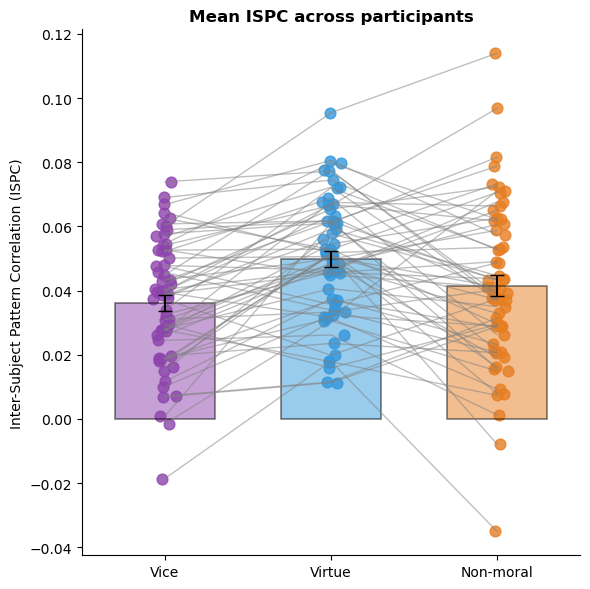

In [7]:

# ================================================================
# Function: Inter-Subject Pattern Correlation (ISPC)
# ================================================================
def run_inter_subject_pattern_correlation(data_array, events):
    """
    Compute inter-subject pattern correlation (ISPC) for each event
    and return the average ISPC per participant.
    
    data_array : np.ndarray
        Shape (voxels x TRs x participants)
    events : pd.DataFrame
        Columns ['startTR', 'endTR']
    
    Returns
    -------
    ispc_per_participant : np.ndarray
        Mean ISPC per participant across all events.
    """
    # Clean and prepare events
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR'] = events['endTR'].astype(int)
    n_events = len(events)
    n_vox, n_tr, n_part = data_array.shape

    # Z-score each participant voxelwise over time
    data_z = np.zeros_like(data_array)
    for p in range(n_part):
        # print('participant; ',p)
        data_z[:, :, p] = zscore(data_array[:, :, p], axis=1, ddof=1)
        # print(np.mean(data_z))

    # Compute mean spatial pattern per event per participant
    event_patterns = np.zeros((n_vox, n_events, n_part))
    for i, ev in events.iterrows():
        start_tr = int(ev['startTR'])
        end_tr = int(ev['endTR'])
        event_patterns[:, i, :] = np.mean(data_z[:, start_tr:end_tr + 1, :], axis=1)

    # Compute ISPC (inter-subject pattern correlation)
    ispc_per_participant = np.zeros(n_part)
    for p in range(n_part):
        others = np.delete(np.arange(n_part), p)
        corrs = []
        for i in range(n_events):
            this_pattern = event_patterns[:, i, p]
            others_mean = np.mean(event_patterns[:, i, others], axis=1)
            
            # nan_indices = np.argwhere(np.isnan(others_mean))
            # print('shape ', others_mean.shape)
            # print(nan_indices)
            
            r, _ = pearsonr(this_pattern, others_mean)
            corrs.append(r)
        ispc_per_participant[p] = np.mean(corrs)
    
    return ispc_per_participant


# ================================================================
# Run ISPC for both hemispheres (moral and non-moral)
# ================================================================
print("Running ISPC for LEFT hemisphere...")
ispc_virtue_part_L = run_inter_subject_pattern_correlation(left, virtue_df)
ispc_vice_part_L = run_inter_subject_pattern_correlation(left, vice_df)
ispc_nonmoral_part_L = run_inter_subject_pattern_correlation(left, nonmoral_df)

print("Running ISPC for RIGHT hemisphere...")
ispc_virtue_part_R = run_inter_subject_pattern_correlation(right, virtue_df)
ispc_vice_part_R = run_inter_subject_pattern_correlation(right, vice_df)
ispc_nonmoral_part_R = run_inter_subject_pattern_correlation(right, nonmoral_df)


# ================================================================
# Average across hemispheres (participant-level)
# ================================================================
# n_participants = min(len(ispc_moral_part_L), len(ispc_moral_part_R),
#                      len(ispc_nonmoral_part_L), len(ispc_nonmoral_part_R))

# ispc_moral_part_avg = (ispc_moral_part_L[:n_participants] + ispc_moral_part_R[:n_participants]) / 2
# ispc_nonmoral_part_avg = (ispc_nonmoral_part_L[:n_participants] + ispc_nonmoral_part_R[:n_participants]) / 2

ispc_virtue_part_avg = (ispc_virtue_part_L + ispc_virtue_part_R) / 2
ispc_vice_part_avg = (ispc_vice_part_L + ispc_vice_part_R) / 2
ispc_nonmoral_part_avg = (ispc_nonmoral_part_L + ispc_nonmoral_part_R) / 2


# ================================================================
# Paired t-test
# ================================================================
tval, pval = ttest_rel(ispc_virtue_part_avg, ispc_vice_part_avg)
tval2, pval2 = ttest_rel(ispc_virtue_part_avg, ispc_nonmoral_part_avg)
tval3, pval3 = ttest_rel(ispc_vice_part_avg, ispc_nonmoral_part_avg)
print("\n===============================")
print("Participant-level ISPC results")
print("===============================")
print(f"virtue vs vice: t = {tval:.2f}, p = {pval:.4f}")
print(f"virtue vs baseline: t = {tval2:.2f}, p = {pval2:.4f}")
print(f"vice vs baseline: t = {tval3:.2f}, p = {pval3:.4f}")


# ================================================================
# Visualization
# ================================================================
fig, ax = plt.subplots(figsize=(6, 6))
x_pos = [0, 1, 2]
colors = ['#8E44AD', '#3498DB', '#E67E22']

# Connect lines per participant
for i in range(len(ispc_vice_part_L)):
    ax.plot(x_pos,
            [ispc_vice_part_avg[i], ispc_virtue_part_avg[i], ispc_nonmoral_part_avg[i]],
            color='gray', alpha=0.5, linewidth=1)

# Add jittered dots
ax.scatter(np.zeros(len(ispc_vice_part_L)) + np.random.normal(0, 0.03, len(ispc_vice_part_L)),
            ispc_vice_part_avg,
            color=colors[0], s=60, alpha=0.8, label='Vice')

ax.scatter(np.ones(len(ispc_vice_part_L)) + np.random.normal(0, 0.03, len(ispc_vice_part_L)),
            ispc_virtue_part_avg,
            color=colors[1], s=60, alpha=0.8, label='Virtue')

ax.scatter((np.ones(len(ispc_vice_part_L))+1) + np.random.normal(0, 0.03, len(ispc_vice_part_L)),
            ispc_nonmoral_part_avg,
            color=colors[2], s=60, alpha=0.8, label='Non-moral')

# Mean + SEM bars
mean_vals = [np.mean(ispc_vice_part_avg), np.mean(ispc_virtue_part_avg), np.mean(ispc_nonmoral_part_avg)]
sem_vals = [np.std(ispc_vice_part_avg)/np.sqrt(len(ispc_vice_part_L)),
            np.std(ispc_virtue_part_avg)/np.sqrt(len(ispc_vice_part_L)),
            np.std(ispc_nonmoral_part_avg)/np.sqrt(len(ispc_vice_part_L))]
ax.bar(x_pos, mean_vals, yerr=sem_vals, color=colors, alpha=0.5, width=0.6,
       capsize=5, edgecolor='black', linewidth=1.2)

# Aesthetics
ax.set_xticks(x_pos)
ax.set_xticklabels(['Vice', 'Virtue', 'Non-moral'])
ax.set_ylabel('Inter-Subject Pattern Correlation (ISPC)')
ax.set_title(f'Mean ISPC across participants',
             fontsize=12, weight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(-0.5, 2.5)
plt.tight_layout()
plt.show()


In [8]:
vice_df.shape

(25, 4)

In [9]:
virtue_df.shape

(42, 4)

In [10]:
nonmoral_df.shape

(20, 4)